**FNN using DeepXDE module**

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d


Data loading

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')

data_I_clean = np.array(np.array(datastore["I_clean"]))
# data_I_noisy = np.array(np.array(datastore["I_noisy"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
keys = list(datastore.keys())

data_p = np.array(np.array(datastore["parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))

t = np.linspace(0, 1, 601).reshape(601, 1)

In [4]:
seeds = [42, 7, 21]
alpha = 0.25
sigma = 9
noise_std = alpha * np.abs(data_I_clean[:, 0] - data_I_clean[:, -1])[:, np.newaxis]
rng = np.random.default_rng(seeds[0])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)
data_I_noisy = data_I_clean * noise
data_I_noisy_1 = np.vstack((data_I_clean, data_I_noisy))
data_c_1 = np.vstack((data_c, data_c))
data_h_1 = np.vstack((data_h, data_h))

rng = np.random.default_rng(seeds[1])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)

data_I_noisy_ii = data_I_clean * noise

data_I_noisy_2 = np.vstack((data_I_noisy_1, data_I_noisy_ii))
data_c_2 = np.vstack((data_c_1, data_c))
data_h_2 = np.vstack((data_h_1, data_h))

rng = np.random.default_rng(seeds[2])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)

data_I_noisy_iii = data_I_clean * noise

data_I_noisy_3 = np.vstack((data_I_noisy_2, data_I_noisy_iii))
data_c_3 = np.vstack((data_c_2, data_c))
data_h_3 = np.vstack((data_h_2, data_h))

Train-test split

In [5]:
train_label, test_label = train_test_split(range(len(data_I_clean)), test_size=0.5, random_state=42)

data_i_clean_train = data_I_clean[train_label,:]
data_i_clean_test = data_I_clean[test_label,:]

data_i_noisy_train = data_I_noisy[train_label,:]
data_i_noisy_test = data_I_noisy[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [6]:
train_label_2, test_label_2 = train_test_split(range(len(data_I_noisy_2)), test_size=0.5, random_state=42)

data_i_noisy_2_train = data_I_noisy_2[train_label_2,:]
data_i_noisy_2_test = data_I_noisy_2[test_label_2,:]

data_c_2_train = data_c_2[train_label_2,:]
data_c_2_test = data_c_2[test_label_2,:]

data_h_2_train = data_h_2[train_label_2,:]
data_h_2_test = data_h_2[test_label_2,:]

In [7]:
train_label_3, test_label_3 = train_test_split(range(len(data_I_noisy_3)), test_size=0.5, random_state=42)

data_i_noisy_3_train = data_I_noisy_3[train_label_3,:]
data_i_noisy_3_test = data_I_noisy_3[test_label_3,:]

data_c_3_train = data_c_3[train_label_3,:]
data_c_3_test = data_c_3[test_label_3,:]

data_h_3_train = data_h_3[train_label_3,:]
data_h_3_test = data_h_3[test_label_3,:]

In [8]:
# Train PCA model
pca_i_clean = PCA(n_components=4, svd_solver='full')
pca_i_clean.fit(data_i_clean_train)

# Number of principal components
n_components_i = pca_i_clean.n_components_
print(f"Number of principal components: {n_components_i}")

# Transform and inverse transform data_i_train
data_i_train_pca_clean = pca_i_clean.transform(data_i_clean_train)
data_i_train_reconstructed_clean = pca_i_clean.inverse_transform(data_i_train_pca_clean)

# Calculate mean squared error for data_i_train
mse_train_clean = np.mean((data_i_clean_train - data_i_train_reconstructed_clean)**2)
print(f"Mean Squared Error for data_i_clean_train: {mse_train_clean}")

# Transform and inverse transform data_i_test
data_i_test_pca_clean = pca_i_clean.transform(data_i_clean_test)
data_i_test_reconstructed_clean = pca_i_clean.inverse_transform(data_i_test_pca_clean)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_clean_test - data_i_test_reconstructed_clean)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_i_clean_train: 1.5845747469901886e-06
Mean Squared Error for data_i_test: 1.5747739979132364e-06


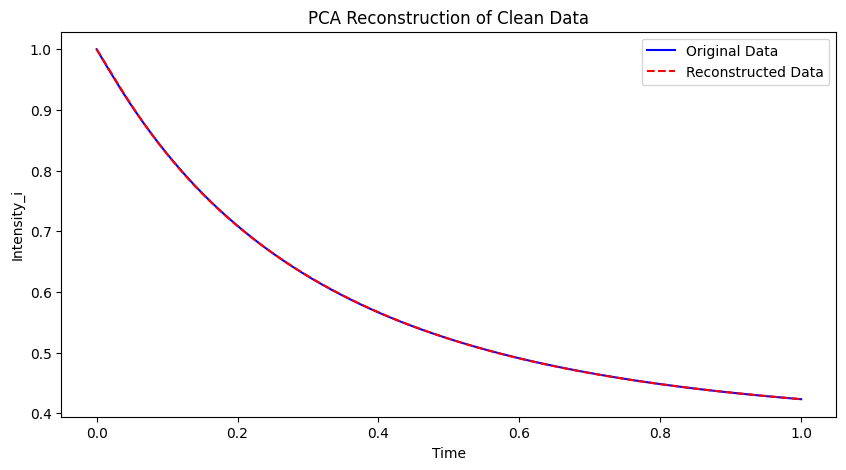

In [9]:
n = np.random.randint(0, len(data_i_clean_train))  # Randomly select an index for plotting
# plot samples from data_i_clean_train and data_i_train_reconstructed_clean
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_clean_train[n], label='Original Data', color='blue')
plt.plot(t, data_i_train_reconstructed_clean[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of Clean Data')
plt.xlabel('Time')
plt.ylabel('Intensity_i')
plt.legend()
plt.show()

In [10]:
# Train PCA model on noisy data
pca_i = PCA(n_components=4, svd_solver='full')
pca_i.fit(data_i_noisy_train)

# Number of principal components
n_components_i = pca_i.n_components_
print(f"Number of principal components: {n_components_i}")

# Transform and inverse transform data_i_train
data_i_train_pca_noisy = pca_i.transform(data_i_noisy_train)
data_i_train_reconstructed_noisy = pca_i.inverse_transform(data_i_train_pca_noisy)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_noisy_train - data_i_train_reconstructed_noisy)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca_noisy = pca_i.transform(data_i_noisy_test)
data_i_test_reconstructed_noisy = pca_i.inverse_transform(data_i_test_pca_noisy)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_noisy_test - data_i_test_reconstructed_noisy)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_i_train: 0.00017011024284425527
Mean Squared Error for data_i_test: 0.00017082980742666627


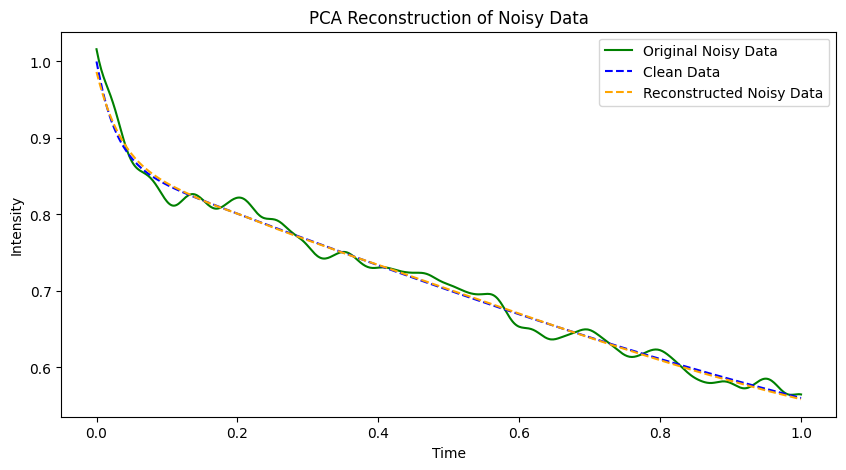

In [11]:
n = np.random.randint(0, len(data_i_noisy_test))

# plot sample from data_i_noisy_train and data_i_train_reconstructed_noisy
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_noisy_test[n], label='Original Noisy Data', color='green')
plt.plot(t, data_i_clean_test[n], label='Clean Data', color='blue', linestyle='--')
plt.plot(t, data_i_test_reconstructed_noisy[n], label='Reconstructed Noisy Data', color='orange', linestyle='--')
plt.title('PCA Reconstruction of Noisy Data')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

In [12]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_c = PCA(n_components=4, svd_solver='full')
pca_c.fit(data_c_train)

# Number of principal components
n_components_c = pca_c.n_components_
print(f"Number of principal components: {n_components_c}")

# Transform and inverse transform data_i_train
data_c_train_pca = pca_c.transform(data_c_train)
data_c_train_reconstructed = pca_c.inverse_transform(data_c_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_c_train - data_c_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_train: {mse_train}")

# Transform and inverse transform data_i_test
data_c_test_pca = pca_c.transform(data_c_test)
data_c_test_reconstructed = pca_c.inverse_transform(data_c_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_c_test - data_c_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_c_train: 1.1305630633786065e-06
Mean Squared Error for data_c_test: 1.0438831338682399e-06


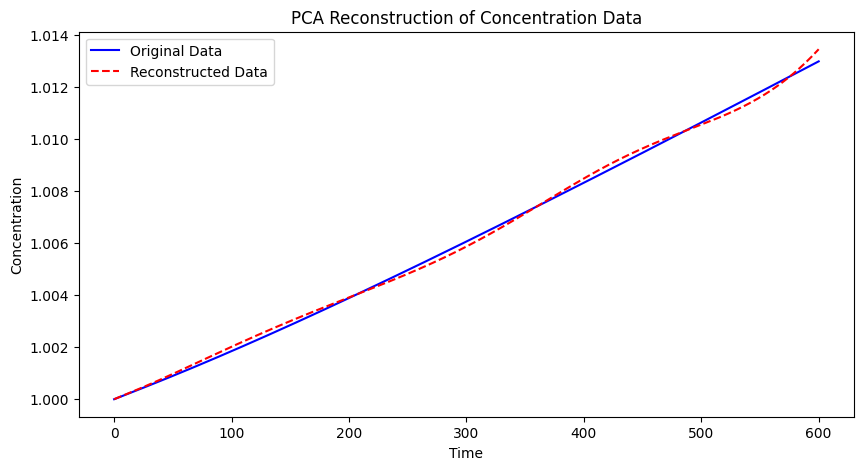

In [13]:
n = np.random.randint(0, len(data_c_train))  # Randomly select an index for plotting
# plot samples from data_c_train and data_c_train_reconstructed

plt.figure(figsize=(10, 5))
plt.plot(data_c_train[n], label='Original Data', color='blue')
plt.plot(data_c_train_reconstructed[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of Concentration Data')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.show()

In [14]:
# Train PCA model
pca_h = PCA(n_components=4, svd_solver='full')
pca_h.fit(data_h_train)

# Number of principal components
n_components_h = pca_h.n_components_
print(f"Number of principal components: {n_components_h}")

# Transform and inverse transform data_i_train
data_h_train_pca = pca_h.transform(data_h_train)
data_h_train_reconstructed = pca_h.inverse_transform(data_h_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_h_train - data_h_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_train: {mse_train}")

# Transform and inverse transform data_i_test
data_h_test_pca = pca_h.transform(data_h_test)
data_h_test_reconstructed = pca_h.inverse_transform(data_h_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_h_test - data_h_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_h_train: 1.014160462336319e-06
Mean Squared Error for data_c_test: 9.819604376024488e-07


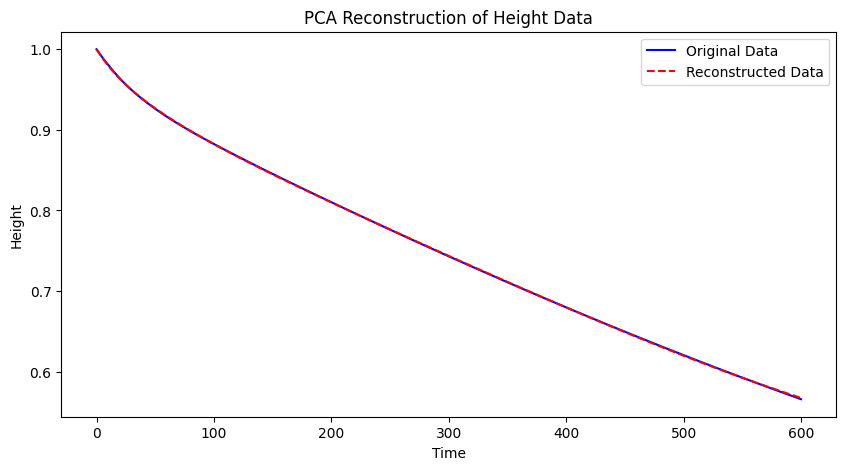

In [15]:
n = np.random.randint(0, len(data_h_train))  # Randomly select an index for plotting

# plot samples from data_h_train and data_h_train_reconstructed
plt.figure(figsize=(10, 5))
plt.plot(data_h_train[n], label='Original Data', color='blue')
plt.plot(data_h_train_reconstructed[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of Height Data')
plt.xlabel('Time')
plt.ylabel('Height')
plt.legend()
plt.show()

In [16]:
pca_i_2 = PCA(n_components=4, svd_solver='full')
pca_i_2.fit(data_i_noisy_2_train)

data_i_noisy_2_train_pca = pca_i_2.transform(data_i_noisy_2_train)
data_i_noisy_2_train_reconstructed = pca_i_2.inverse_transform(data_i_noisy_2_train_pca)

# Calculate mean squared error for data_i_noisy_2_train
mse_train_2 = np.mean((data_i_noisy_2_train - data_i_noisy_2_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_noisy_2_train: {mse_train_2}")

# Transform and inverse transform data_i_noisy_2_test
data_i_noisy_2_test_pca = pca_i_2.transform(data_i_noisy_2_test)
data_i_2_noisy_test_reconstructed = pca_i_2.inverse_transform(data_i_noisy_2_test_pca)

# Calculate mean squared error for data_i_noisy_2_test
mse_test_2 = np.mean((data_i_noisy_2_test - data_i_2_noisy_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_noisy_2_test: {mse_test_2}")

Mean Squared Error for data_i_noisy_2_train: 0.00011469305962537837
Mean Squared Error for data_i_noisy_2_test: 0.00011513194457318411


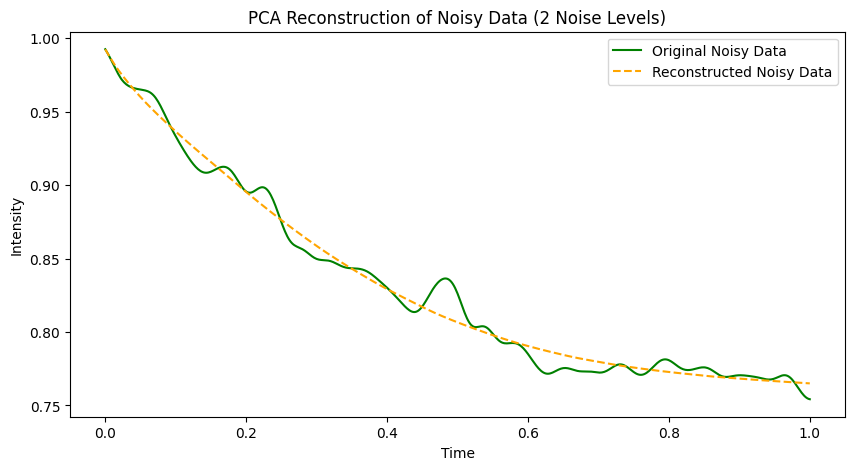

In [17]:
n = np.random.randint(0, len(data_i_noisy_2_train))  # Randomly select an index for plotting

# Plot samples from data_i_noisy_2_train and data_i_noisy_2_train_reconstructed
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_noisy_2_train[n], label='Original Noisy Data', color='green')
plt.plot(t, data_i_noisy_2_train_reconstructed[n], label='Reconstructed Noisy Data', color='orange', linestyle='--')
plt.title('PCA Reconstruction of Noisy Data (2 Noise Levels)')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

In [18]:
pca_c_2 = PCA(n_components=4, svd_solver='full')
pca_c_2.fit(data_c_2_train)

data_c_2_train_pca = pca_c_2.transform(data_c_2_train)
data_c_2_train_reconstructed = pca_c_2.inverse_transform(data_c_2_train_pca)

# Calculate mean squared error for data_c_2_train
mse_train_2 = np.mean((data_c_2_train - data_c_2_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_2_train: {mse_train_2}")

# Transform and inverse transform data_c_2_test
data_c_2_test_pca = pca_c_2.transform(data_c_2_test)
data_c_2_test_reconstructed = pca_c_2.inverse_transform(data_c_2_test_pca)

# Calculate mean squared error for data_c_2_test
mse_test_2 = np.mean((data_c_2_test - data_c_2_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_2_test: {mse_test_2}")

Mean Squared Error for data_c_2_train: 1.089678020176244e-06
Mean Squared Error for data_c_2_test: 1.081369138503582e-06


In [19]:
pca_h_2 = PCA(n_components=4, svd_solver='full')
pca_h_2.fit(data_h_2_train)

data_h_2_train_pca = pca_h_2.transform(data_h_2_train)
data_h_2_train_reconstructed = pca_h_2.inverse_transform(data_h_2_train_pca)

# Calculate mean squared error for data_h_2_train
mse_train_2 = np.mean((data_h_2_train - data_h_2_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_2_train: {mse_train_2}")

# Calculate mean squared error for data_h_2_test
data_h_2_test_pca = pca_h_2.transform(data_h_2_test)
data_h_2_test_reconstructed = pca_h_2.inverse_transform(data_h_2_test_pca)
mse_test_2 = np.mean((data_h_2_test - data_h_2_test_reconstructed)**2)
print(f"Mean Squared Error for data_h_2_test: {mse_test_2}")

Mean Squared Error for data_h_2_train: 1.005385281901066e-06
Mean Squared Error for data_h_2_test: 9.90550198762846e-07


In [20]:
pca_i_3 = PCA(n_components=4, svd_solver='full')
pca_i_3.fit(data_i_noisy_3_train)

data_i_noisy_3_train_pca = pca_i_3.transform(data_i_noisy_3_train)
data_i_noisy_3_train_reconstructed = pca_i_3.inverse_transform(data_i_noisy_3_train_pca)

# Calculate mean squared error for data_i_noisy_3_train
mse_train_3 = np.mean((data_i_noisy_3_train - data_i_noisy_3_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_noisy_3_train: {mse_train_3}")

# Calculate mean squared error for data_i_noisy_3_test
data_i_3_noisy_test_pca = pca_i_3.transform(data_i_noisy_3_test)
data_i_3_noisy_test_reconstructed = pca_i_3.inverse_transform(data_i_3_noisy_test_pca)
mse_test_3 = np.mean((data_i_noisy_3_test - data_i_3_noisy_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_noisy_3_test: {mse_test_3}")

Mean Squared Error for data_i_noisy_3_train: 0.0001289633722768284
Mean Squared Error for data_i_noisy_3_test: 0.0001288021408101193


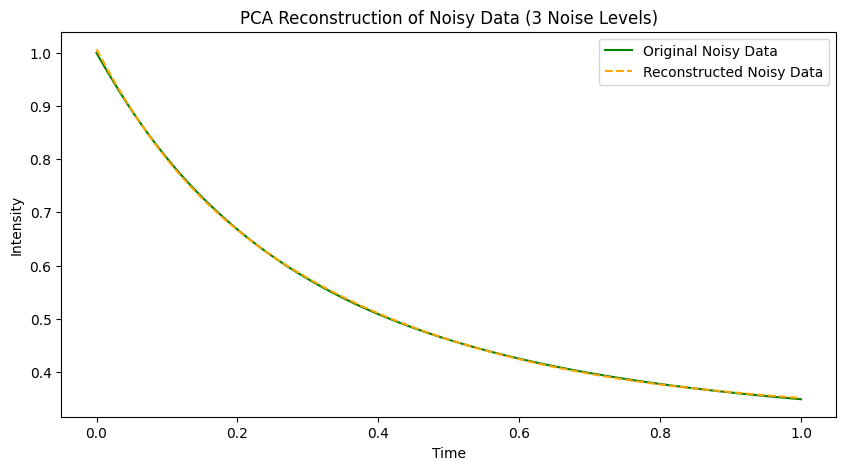

In [21]:
n = np.random.randint(0, len(data_i_noisy_3_train))  # Randomly select an index for plotting

# plot sample from data_i_noisy_3_train and data_i_3_train_reconstructed
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_noisy_3_train[n], label='Original Noisy Data', color='green')
plt.plot(t, data_i_noisy_3_train_reconstructed[n], label='Reconstructed Noisy Data', color='orange', linestyle='--')
plt.title('PCA Reconstruction of Noisy Data (3 Noise Levels)')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

In [22]:
pca_c_3 = PCA(n_components=4, svd_solver='full')
pca_c_3.fit(data_c_3_train)

data_c_3_train_pca = pca_c_3.transform(data_c_3_train)
data_c_3_train_reconstructed = pca_c_3.inverse_transform(data_c_3_train_pca)

# Calculate mean squared error for data_c_3_train
mse_train_3 = np.mean((data_c_3_train - data_c_3_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_3_train: {mse_train_3}")

# Calculate mean squared error for data_c_3_test
data_c_3_test_pca = pca_c_3.transform(data_c_3_test)
data_c_3_test_reconstructed = pca_c_3.inverse_transform(data_c_3_test_pca)
mse_test_3 = np.mean((data_c_3_test - data_c_3_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_3_test: {mse_test_3}")

Mean Squared Error for data_c_3_train: 1.0924033051026955e-06
Mean Squared Error for data_c_3_test: 1.078238273375085e-06


In [23]:
pca_h_3 = PCA(n_components=4, svd_solver='full')
pca_h_3.fit(data_h_3_train)

data_h_3_train_pca = pca_h_3.transform(data_h_3_train)
data_h_3_train_reconstructed = pca_h_3.inverse_transform(data_h_3_train_pca)

# Calculate mean squared error for data_h_3_train
mse_train_3 = np.mean((data_h_3_train - data_h_3_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_3_train: {mse_train_3}")

# Calculate mean squared error for data_h_3_test
data_h_3_test_pca = pca_h_3.transform(data_h_3_test)
data_h_3_test_reconstructed = pca_h_3.inverse_transform(data_h_3_test_pca)
mse_test_3 = np.mean((data_h_3_test - data_h_3_test_reconstructed)**2)
print(f"Mean Squared Error for data_h_3_test: {mse_test_3}")

Mean Squared Error for data_h_3_train: 9.976370521004428e-07
Mean Squared Error for data_h_3_test: 9.98351012043227e-07


# Model_c trained on Clean data and only noisy data

In [24]:
X_train_clean = data_i_train_pca_clean.astype(np.float32)
X_train_noisy = data_i_train_pca_noisy.astype(np.float32)
y_train_c = data_c_train_pca.astype(np.float32)

In [25]:
X_test_clean = data_i_test_pca_clean.astype(np.float32)
X_test_noisy = data_i_test_pca_noisy.astype(np.float32)
y_test_c = data_c_test_pca.astype(np.float32)

In [26]:
data_c_clean = dde.data.dataset.DataSet(
    X_train=X_train_clean, y_train=y_train_c, X_test=X_test_clean, y_test=y_test_c
)

data_c_noisy = dde.data.dataset.DataSet(
    X_train=X_train_noisy, y_train=y_train_c, X_test=X_test_noisy, y_test=y_test_c
)

In [27]:
net_c_clean = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_c],
    "relu",
    "Glorot normal",
)

net_c_noisy = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_c],
    "relu",
    "Glorot normal",
)

In [28]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [n_components_i, 300, 300, 300, n_components_c]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 183304


In [29]:
model_c_clean = dde.Model(data_c_clean, net_c_clean)
model_c_noisy = dde.Model(data_c_noisy, net_c_noisy)

In [30]:
model_c_clean.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_clean-1000.ckpt'
model_c_clean.restore(path)
# losshistory_c_clean, train_state_c_clean = model_c_clean.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.430589 s


'compile' took 1.329363 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_clean-1000.ckpt


In [31]:
model_c_noisy.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy-1000.ckpt'
model_c_noisy.restore(path)
# losshistory_c_noisy, train_state_c_noisy = model_c_noisy.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.067953 s

'compile' took 0.230031 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy-1000.ckpt


In [32]:
# model_c.compile("adam", lr=0.0001, loss="mse", metrics=["l2 relative error"])
# losshistory_c, train_state_c = model_c.train(iterations=500, display_every=100)

# Model_c trained on Clean data + 1 copy of noisy data

In [33]:
X_train_noisy_2 = data_i_noisy_2_train_pca.astype(np.float32)
y_train_c_2 = data_c_2_train_pca.astype(np.float32)

X_test_noisy_2 = data_i_noisy_2_test_pca.astype(np.float32)
y_test_c_2 = data_c_2_test_pca.astype(np.float32)

In [34]:
data_c_noisy_2 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_2, y_train=y_train_c_2, X_test=X_test_noisy_2, y_test=y_test_c_2
)

net_c_noisy_2 = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_c],
    "relu",
    "Glorot normal",
)

In [35]:
model_c_noisy_2 = dde.Model(data_c_noisy_2, net_c_noisy_2)
model_c_noisy_2.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt'
model_c_noisy_2.restore(path)
# losshistory_c_noisy_2, train_state_c_noisy_2 = model_c_noisy_2.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.072615 s

'compile' took 0.253696 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt


# Model_c trained on Clean data + 2 copies of noisy data

In [36]:
X_train_noisy_3 = data_i_noisy_3_train_pca.astype(np.float32)
y_train_c_3 = data_c_3_train_pca.astype(np.float32)

X_test_noisy_3 = data_i_3_noisy_test_pca.astype(np.float32)
y_test_c_3 = data_c_3_test_pca.astype(np.float32)
data_c_noisy_3 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_3, y_train=y_train_c_3, X_test=X_test_noisy_3, y_test=y_test_c_3
)

net_c_noisy_3 = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_c],
    "relu",
    "Glorot normal",
)

In [37]:
model_c_noisy_3 = dde.Model(data_c_noisy_3, net_c_noisy_3)
model_c_noisy_3.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt'
model_c_noisy_3.restore(path)
# losshistory_c_noisy_3, train_state_c_noisy_3 = model_c_noisy_3.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.064792 s

'compile' took 0.245740 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt


# Model_h trained on Clean data and only noisy data

In [38]:
y_train_h = data_h_train_pca.astype(np.float32)
y_test_h = data_h_test_pca.astype(np.float32)

In [39]:
data_h_clean = dde.data.dataset.DataSet(
    X_train=X_train_clean, y_train=y_train_h, X_test=X_test_clean, y_test=y_test_h
)

data_h_noisy = dde.data.dataset.DataSet(
    X_train=X_train_noisy, y_train=y_train_h, X_test=X_test_noisy, y_test=y_test_h
)

In [40]:
m = 601
dim_x = 1
net_h_clean = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_h],
    "relu",
    "Glorot normal",
)

net_h_noisy = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_h],
    "relu",
    "Glorot normal",
)

In [41]:
model_h_clean = dde.Model(data_h_clean, net_h_clean)
model_h_noisy = dde.Model(data_h_noisy, net_h_noisy)

In [43]:
model_h_clean.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_clean-1000.ckpt'
# model_h_clean.restore(path)
losshistory_h_clean, train_state_h_clean = model_h_clean.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 0.134022 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.69e+00]    [2.64e+00]    [9.89e-01]    
100       [1.07e-01]    [1.01e-01]    [1.93e-01]    
200       [7.27e-02]    [7.03e-02]    [1.62e-01]    
300       [6.47e-02]    [6.29e-02]    [1.53e-01]    
400       [6.53e-02]    [6.34e-02]    [1.53e-01]    
500       [5.77e-02]    [5.67e-02]    [1.45e-01]    
600       [5.95e-02]    [5.93e-02]    [1.48e-01]    
700       [5.57e-02]    [5.58e-02]    [1.44e-01]    
800       [5.27e-02]    [5.40e-02]    [1.42e-01]    
900       [5.29e-02]    [5.46e-02]    [1.42e-01]    
1000      [4.73e-02]    [4.95e-02]    [1.36e-01]    

Best model at step 1000:
  train loss: 4.73e-02
  test loss: 4.95e-02
  test metric: [1.36e-01]

'train' took 51.618635 s



In [45]:
model_h_noisy.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy-1000.ckpt'
# model_h_noisy.restore(path)
losshistory_h_noisy, train_state_h_noisy = model_h_noisy.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 0.139951 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.69e+00]    [2.64e+00]    [9.90e-01]    
100       [1.24e-01]    [1.20e-01]    [2.11e-01]    
200       [1.11e-01]    [1.11e-01]    [2.03e-01]    
300       [1.07e-01]    [1.09e-01]    [2.01e-01]    
400       [1.04e-01]    [1.08e-01]    [2.00e-01]    
500       [1.02e-01]    [1.08e-01]    [2.00e-01]    
600       [1.00e-01]    [1.08e-01]    [2.00e-01]    
700       [9.94e-02]    [1.09e-01]    [2.01e-01]    
800       [9.86e-02]    [1.10e-01]    [2.02e-01]    
900       [9.67e-02]    [1.09e-01]    [2.02e-01]    
1000      [9.51e-02]    [1.10e-01]    [2.02e-01]    

Best model at step 1000:
  train loss: 9.51e-02
  test loss: 1.10e-01
  test metric: [2.02e-01]

'train' took 50.854616 s



# Model_h trained on clean data + 1 copy of noisy data

In [46]:
y_train_h_2 = data_h_2_train_pca.astype(np.float32)
y_test_h_2 = data_h_2_test_pca.astype(np.float32)

data_h_noisy_2 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_2, y_train=y_train_h_2, X_test=X_test_noisy_2, y_test=y_test_h_2
)

net_h_noisy_2 = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_h],
    "relu",
    "Glorot normal",
)

model_h_noisy_2 = dde.Model(data_h_noisy_2, net_h_noisy_2)
model_h_noisy_2.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy2-1000.ckpt'
model_h_noisy_2.restore(path)
# losshistory_h_noisy_2, train_state_h_noisy_2 = model_h_noisy_2.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.069663 s

'compile' took 0.312061 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy2-1000.ckpt


NotFoundError: Restoring from checkpoint failed. This is most likely due to a Variable name or other graph key that is missing from the checkpoint. Please ensure that you have not altered the graph expected based on the checkpoint. Original error:

Graph execution error:

Detected at node 'save_6/RestoreV2' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "c:\Users\arnab\anaconda3\envs\DeepXDETF\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    File "c:\Users\arnab\anaconda3\envs\DeepXDETF\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    File "c:\Users\arnab\anaconda3\envs\DeepXDETF\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    File "c:\Users\arnab\anaconda3\envs\DeepXDETF\Lib\site-packages\tornado\platform\asyncio.py", line 205, in start
    File "c:\Users\arnab\anaconda3\envs\DeepXDETF\Lib\asyncio\base_event

# Model_h trained on Clean data + 2 copies of noisy data

In [ ]:
y_train_h_3 = data_h_3_train_pca.astype(np.float32)
y_test_h_3 = data_h_3_test_pca.astype(np.float32)

data_h_noisy_3 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_3, y_train=y_train_h_3, X_test=X_test_noisy_3, y_test=y_test_h_3
)

net_h_noisy_3 = dde.nn.fnn.FNN(
    [n_components_i, 300, 300, 300, n_components_h],
    "relu",
    "Glorot normal",
)

model_h_noisy_3 = dde.Model(data_h_noisy_3, net_h_noisy_3)
model_h_noisy_3.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy3-1000.ckpt'
# model_h_noisy_3.restore(path)
losshistory_h_noisy_3, train_state_h_noisy_3 = model_h_noisy_3.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.059368 s

'compile' took 0.333001 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.67e+00]    [2.65e+00]    [9.90e-01]    


KeyboardInterrupt: 

# Testing the models trained on clean data and noisy data on their respective test sets

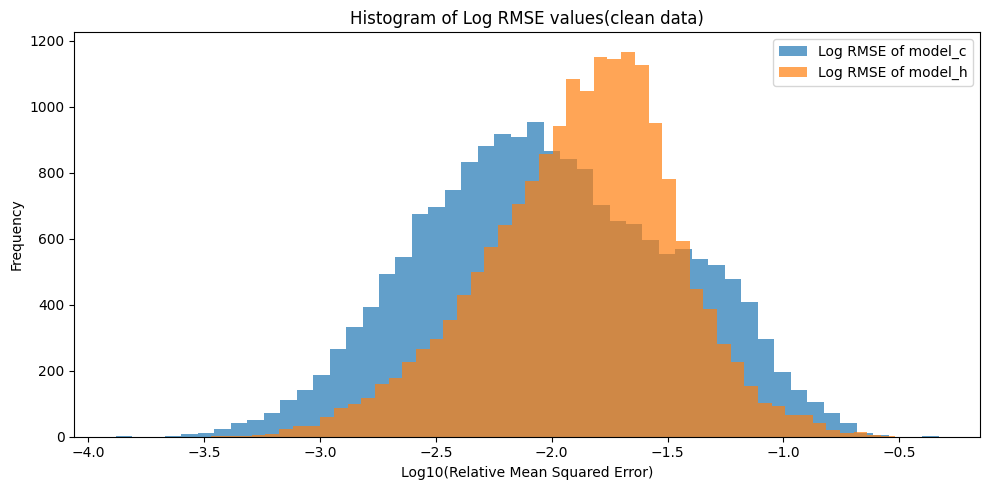

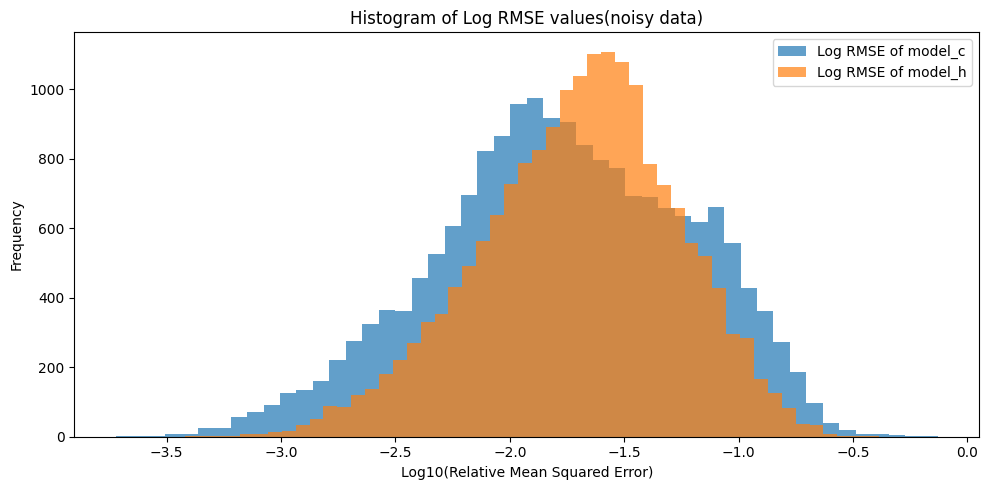

In [51]:
# Use trained model to make predictions
predictions_c_clean = pca_c.inverse_transform(model_c_clean.predict(data_i_test_pca_clean))  # Ensure model_c is defined
predictions_h_clean = pca_h.inverse_transform(model_h_clean.predict(data_i_test_pca_clean))  # Ensure model_h is defined
predictions_c_noisy = pca_c.inverse_transform(model_c_noisy.predict(data_i_test_pca_noisy))  # Ensure model_c is defined
predictions_h_noisy = pca_h.inverse_transform(model_h_noisy.predict(data_i_test_pca_noisy))  # Ensure model_h is defined
# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_clean = np.sqrt(np.sum((predictions_c_clean - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1))  # Averaging across time points
rrmse_h_clean = np.sqrt(np.sum((predictions_h_clean - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1))  # Averaging across time points

rrmse_c_noisy = np.sqrt(np.sum((predictions_c_noisy - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1))  # Averaging across time points
rrmse_h_noisy = np.sqrt(np.sum((predictions_h_noisy - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1))  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(clean data)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(noisy data)')
plt.legend()
plt.tight_layout()
plt.show()

# Testing the models trained on clean data + 1 copy noisy data on their respective test sets

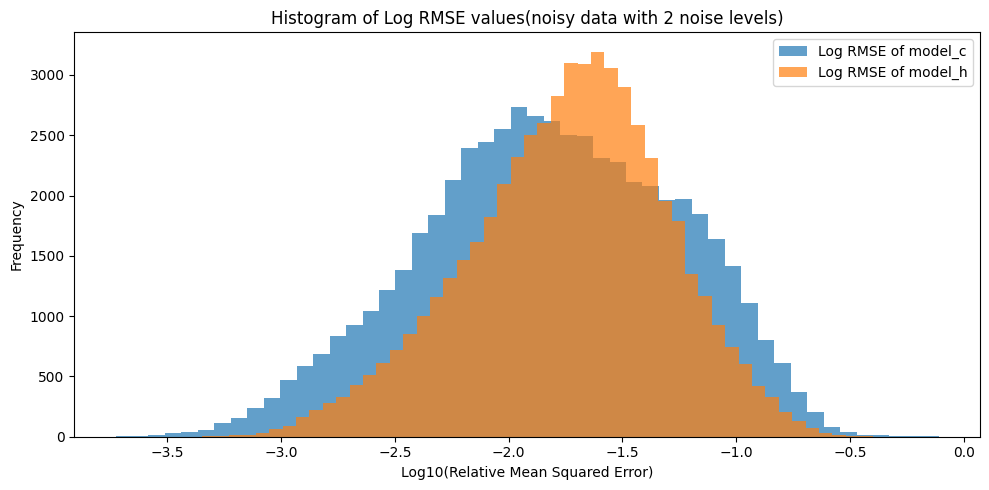

In [52]:
predictions_c_noisy_2 = pca_c.inverse_transform(model_c_noisy_2.predict(data_i_noisy_2_test_pca))  # Ensure model_c is defined
predictions_h_noisy_2 = pca_h.inverse_transform(model_h_noisy_2.predict(data_i_noisy_2_test_pca))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_noisy_2 = np.sqrt(np.sum((predictions_c_noisy_2 - data_c_2_test) ** 2, axis=1) / np.sum((data_c_2_test ** 2), axis=1))  # Averaging across time points
rrmse_h_noisy_2 = np.sqrt(np.sum((predictions_h_noisy_2 - data_h_2_test) ** 2, axis=1) / np.sum((data_h_2_test ** 2), axis=1))  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(noisy data with 2 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

# Testing the models trained on clean data + 2 copies of noisy data on their respective test sets

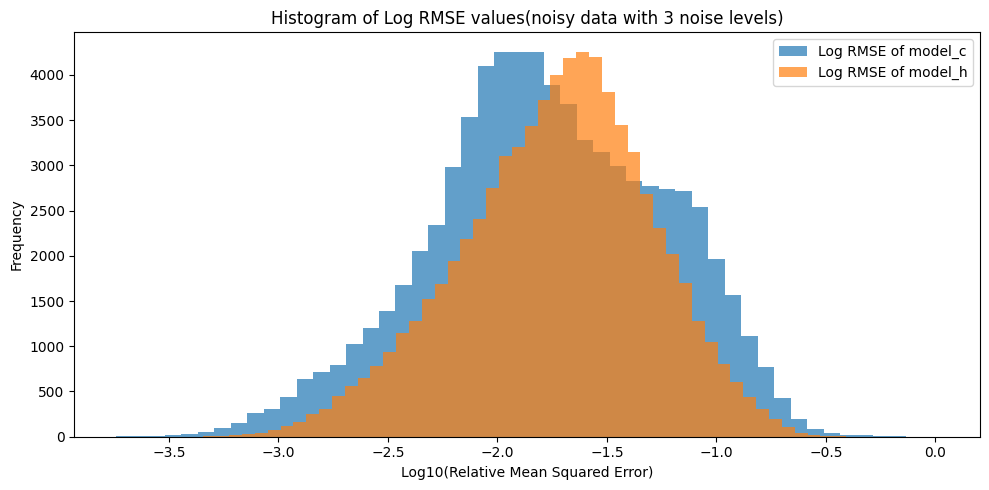

In [54]:
predictions_c_noisy_3 = pca_c.inverse_transform(model_c_noisy_3.predict(data_i_3_noisy_test_pca))  # Ensure model_c is defined
predictions_h_noisy_3 = pca_h.inverse_transform(model_h_noisy_3.predict(data_i_3_noisy_test_pca))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_noisy_3 = np.sqrt(np.sum((predictions_c_noisy_3 - data_c_3_test) ** 2, axis=1) / np.sum((data_c_3_test ** 2), axis=1))  # Averaging across time points
rrmse_h_noisy_3 = np.sqrt(np.sum((predictions_h_noisy_3 - data_h_3_test) ** 2, axis=1) / np.sum((data_h_3_test ** 2), axis=1))  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(noisy data with 3 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

True PCA c: [-8.04923246  0.07496906 -0.12834687  0.00959806]
Predicted PCA c (clean): [[-8.1506748e+00  7.9598129e-02 -1.4017308e-01  7.3251836e-03]]
Predicted PCA c (noisy): [[-8.1738949e+00  3.6317244e-02 -1.1748018e-01  5.7532880e-03]]
True PCA h: [ 0.95405861 -0.12868395  0.16530458  0.00791932]
Predicted PCA h (clean): [[ 0.7565921  -0.18941037  0.17604677  0.00490144]]
Predicted PCA h (noisy): [[ 0.80968684 -0.1578897   0.17877662  0.00598926]]


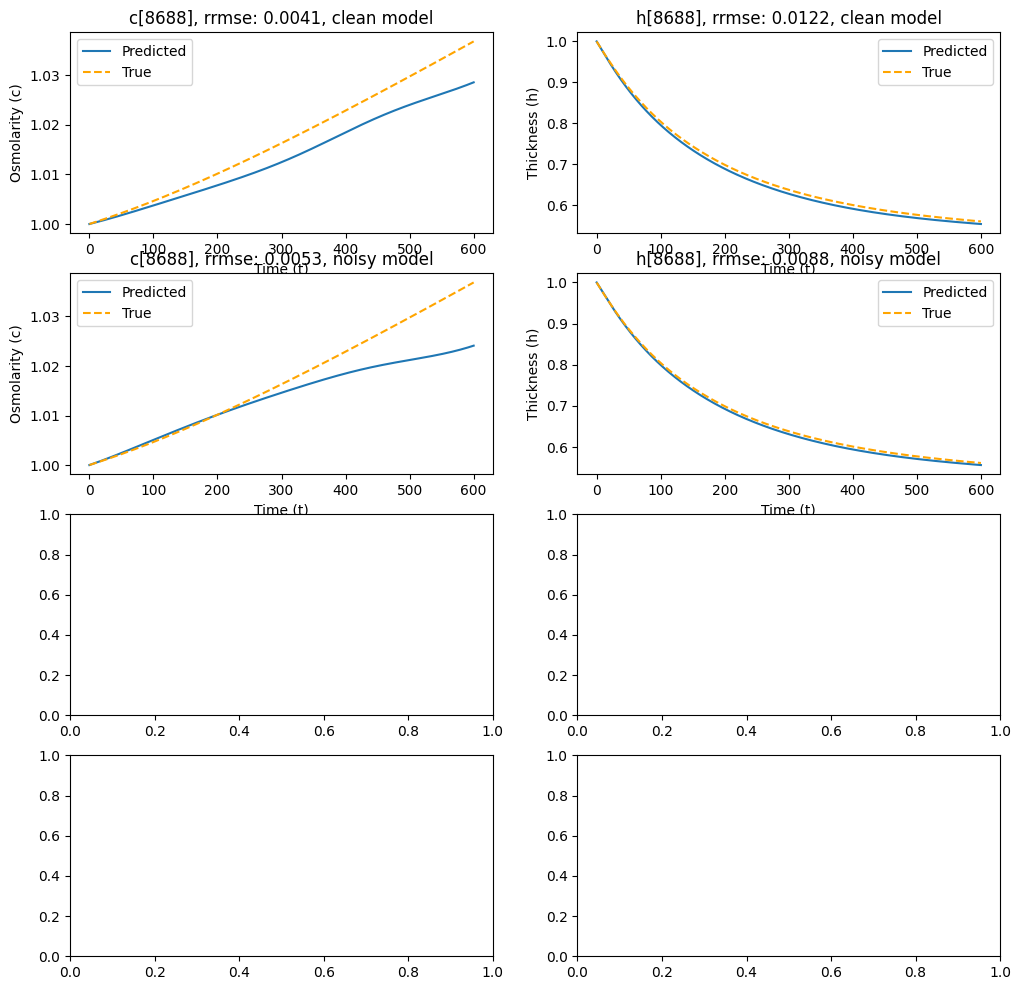

In [55]:
n = np.random.choice(len(data_i_test_pca_clean))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c_clean = model_c_clean.predict(data_i_test_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(data_i_test_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = data_h_test_pca[n]
pred_pca_h_clean = model_h_clean.predict(data_i_test_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(data_i_test_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(4, 2, figsize=(12, 12))  # 4 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])



print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

In [ ]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_clean"
model_c_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_clean-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_clean-1000.ckpt'

In [ ]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy"
model_c_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy-1000.ckpt'

In [48]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_clean"
model_h_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_clean-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_clean-1000.ckpt'

In [49]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy"
model_h_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy-1000.ckpt'

In [56]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2"
model_c_noisy_2.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2_noisy2-1000.ckpt'

In [57]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy2"
model_h_noisy_2.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy2-1000.ckpt'

In [58]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_c_fnn_pca2_noisy3"
model_c_noisy_3.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_c_fnn_pca2_noisy3-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_c_fnn_pca2_noisy3-1000.ckpt'

In [59]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy3"
model_h_noisy_3.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy3-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2_noisy3-1000.ckpt'

In [62]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)


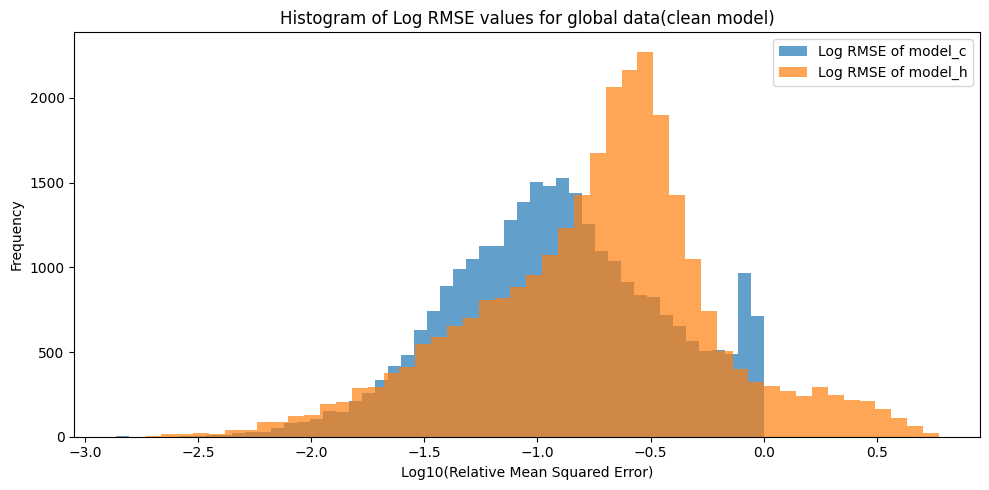

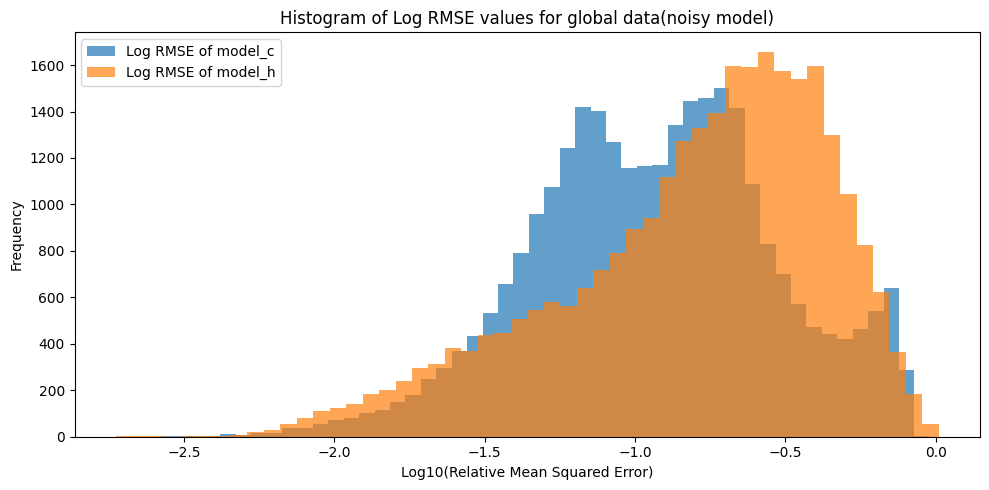

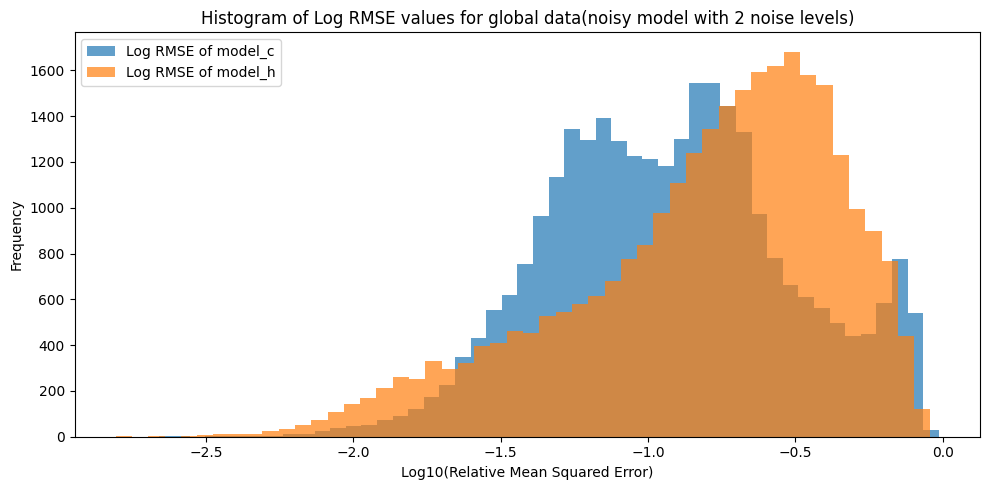

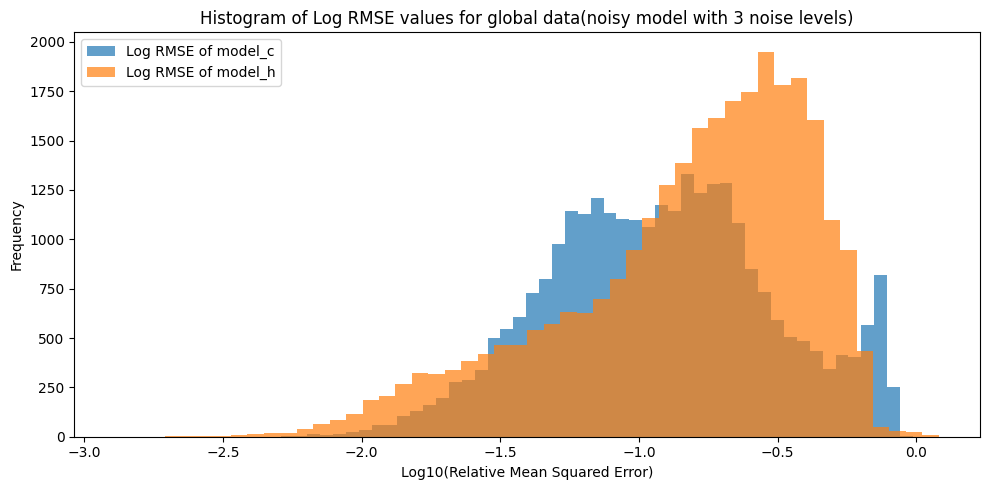

In [63]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
X_test_glob_pca_clean = pca_i_clean.transform(X_test_glob)
X_test_glob_pca_noisy = pca_i.transform(X_test_glob)

y_test_c_glob = data_c_glob.astype(np.float32)
y_test_c_glob_pca = pca_c.transform(y_test_c_glob)
y_test_h_glob = data_h_glob.astype(np.float32)
y_test_h_glob_pca = pca_h.transform(y_test_h_glob)

# Use trained models to make predictions
predictions_c_glob_clean = pca_c.inverse_transform(model_c_clean.predict(X_test_glob_pca_clean))
predictions_h_glob_clean = pca_h.inverse_transform(model_h_clean.predict(X_test_glob_pca_clean))

predictions_c_glob_noisy = pca_c.inverse_transform(model_c_noisy.predict(X_test_glob_pca_noisy))
predictions_h_glob_noisy = pca_h.inverse_transform(model_h_noisy.predict(X_test_glob_pca_noisy))

predictions_c_glob_noisy_2 = pca_c.inverse_transform(model_c_noisy_2.predict(X_test_glob_pca_noisy))
predictions_h_glob_noisy_2 = pca_h.inverse_transform(model_h_noisy_2.predict(X_test_glob_pca_noisy))

predictions_c_glob_noisy_3 = pca_c.inverse_transform(model_c_noisy_3.predict(X_test_glob_pca_noisy))
predictions_h_glob_noisy_3 = pca_h.inverse_transform(model_h_noisy_3.predict(X_test_glob_pca_noisy))

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob_clean = np.sqrt(np.sum((predictions_c_glob_clean - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_clean = np.sqrt(np.sum((predictions_h_glob_clean - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy = np.sqrt(np.sum((predictions_c_glob_noisy - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy = np.sqrt(np.sum((predictions_h_glob_noisy - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy_2 = np.sqrt(np.sum((predictions_c_glob_noisy_2 - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy_2 = np.sqrt(np.sum((predictions_h_glob_noisy_2 - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy_3 = np.sqrt(np.sum((predictions_c_glob_noisy_3 - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy_3 = np.sqrt(np.sum((predictions_h_glob_noisy_3 - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(clean model)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(noisy model)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(noisy model with 2 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(noisy model with 3 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

5414


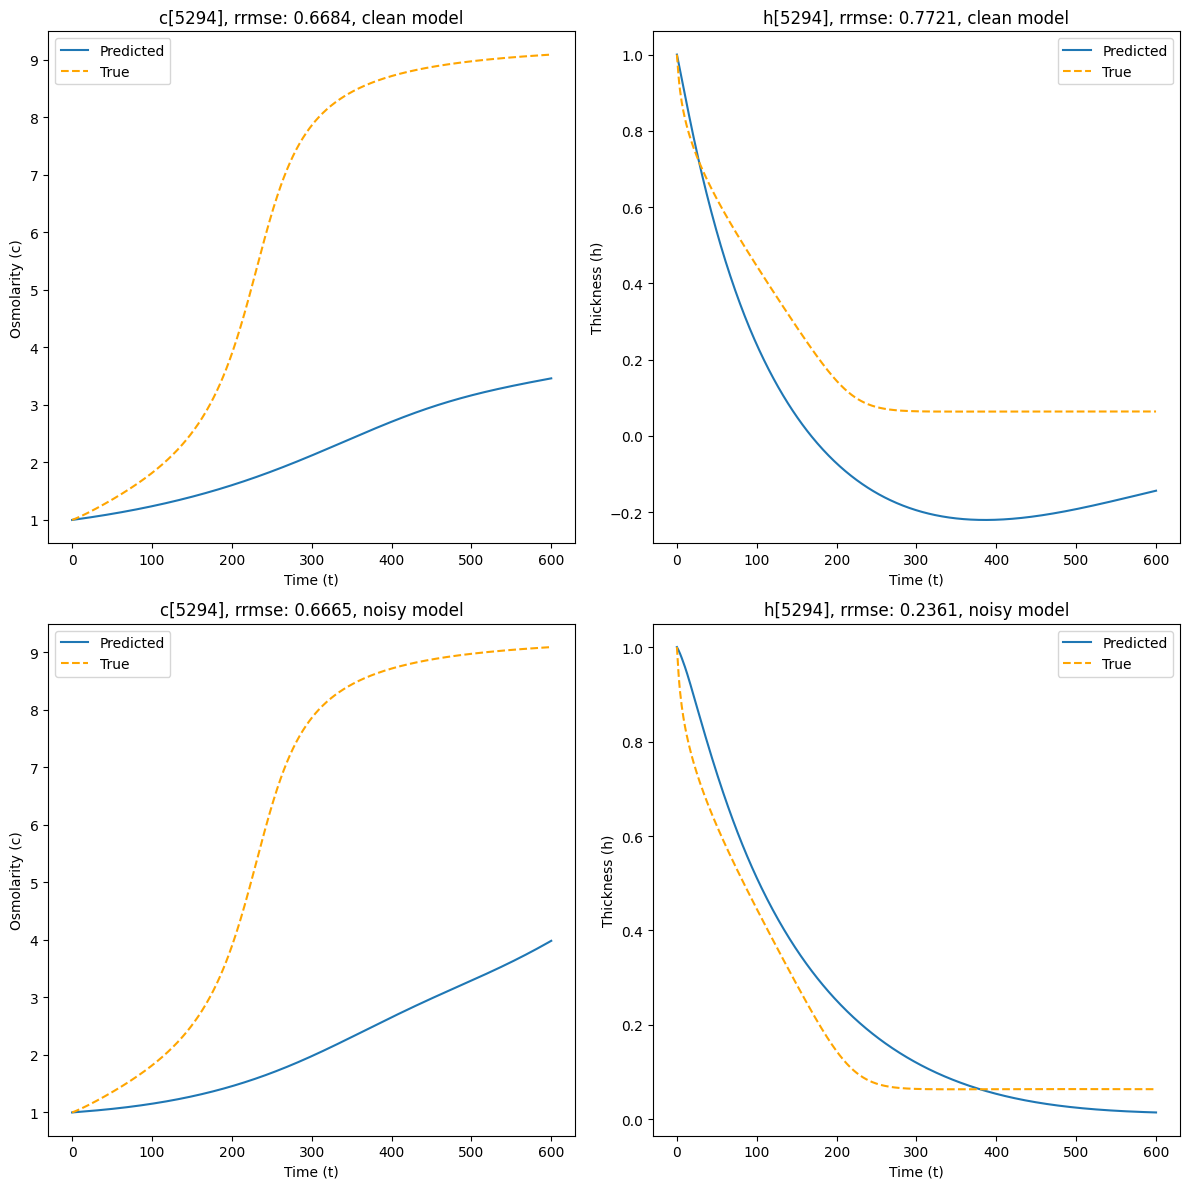

True PCA c: [132.79101712 -32.71285274   3.70055417  10.28524507]
Predicted PCA c (clean): [[26.392525   -1.715498   -0.39923126  0.26122123]]
Predicted PCA c (noisy): [[27.837114    1.9362242  -1.0156753   0.79106957]]
True PCA h: [-10.88017631  -2.36328818   0.74277171  -0.23386474]
Predicted PCA h (clean): [[-16.460241    -3.1886938    1.2339209   -0.12003423]]
Predicted PCA h (noisy): [[-10.44294     -0.8343952    0.86337435   0.12302686]]


In [40]:
n = np.random.randint(0, len(X_test_glob))
print(n)
n = np.random.choice(len(data_i_test_pca_clean))  # Randomly select an index for testing
true_pca_c = y_test_c_glob_pca[n]
pred_pca_c_clean = model_c_clean.predict(X_test_glob_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(X_test_glob_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = y_test_h_glob_pca[n]
pred_pca_h_clean = model_h_clean.predict(X_test_glob_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(X_test_glob_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(y_test_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_glob_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(y_test_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_glob_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(y_test_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_glob_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(y_test_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_glob_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

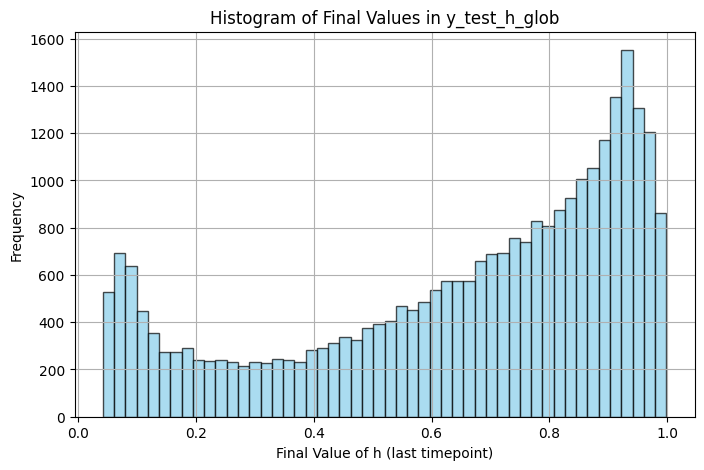

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(y_test_h_glob[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

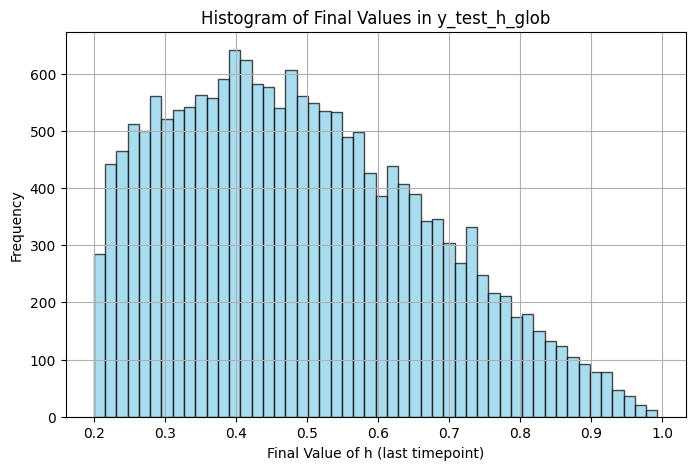

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(data_h_test[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_clean.steps, np.log10(losshistory_c_clean.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_clean.steps, np.log10(losshistory_c_clean.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'losshistory_c_clean' is not defined

<Figure size 800x500 with 0 Axes>

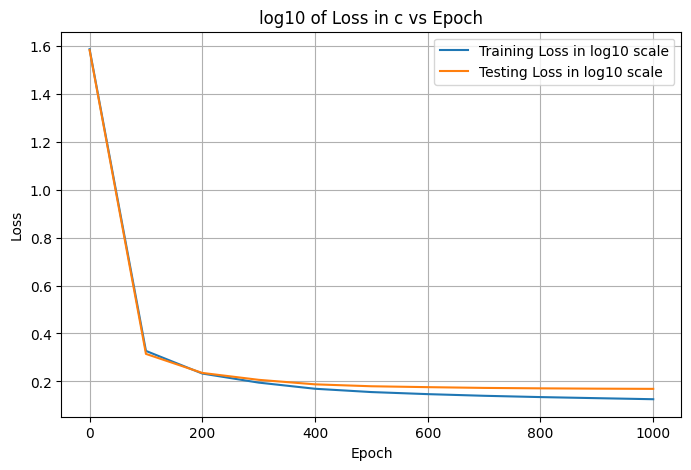

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

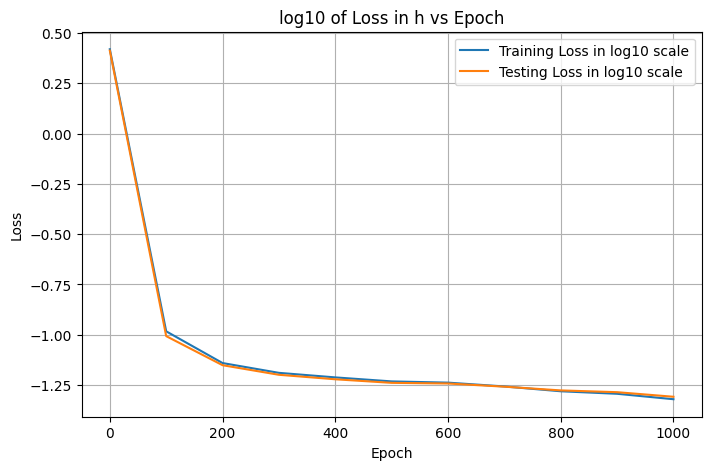

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h_clean.steps, np.log10(losshistory_h_clean.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_h_clean.steps, np.log10(losshistory_h_clean.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in h vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

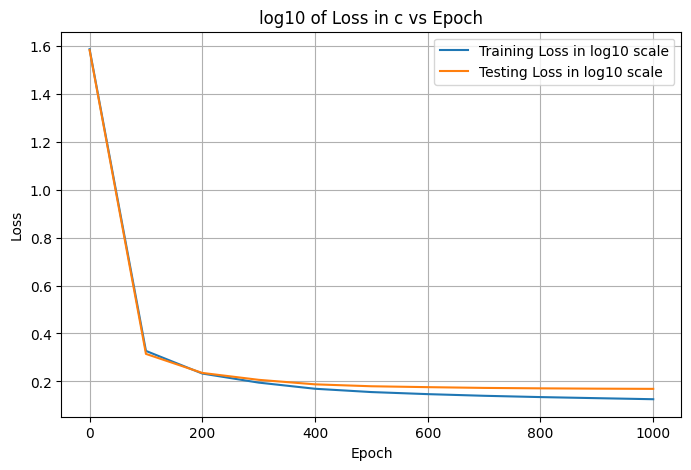

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Testing the model on experimental data

In [65]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [66]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [67]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [68]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [69]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [70]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])
J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f_0_exp = data_p_experimental_nondimensional[:, 4]
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_exp = data_p_experimental_nondimensional[:, 7]
ts_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore.close()  # Close the read-only handle

Mean Squared Error for PCA reconstruction of I_scaled_interp: 9.90373927206845e-05


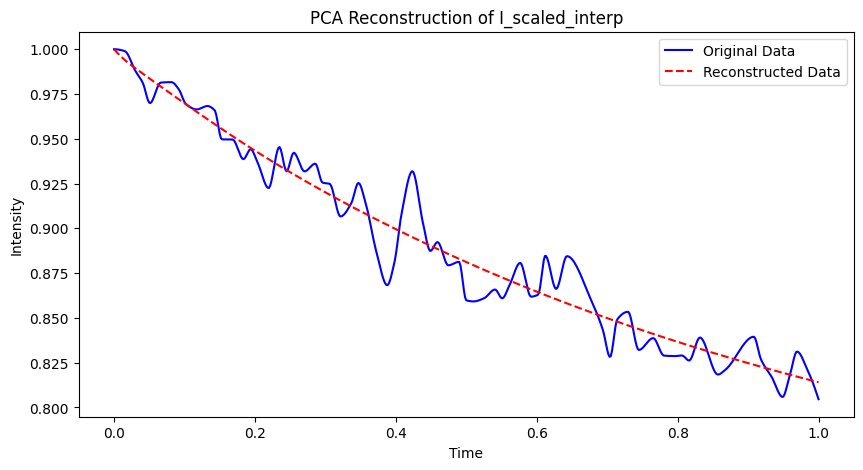

In [71]:
# Transform and inverse transform I_scaled_interp using pca_i_clean
I_scaled_interp_pca = pca_i_clean.transform(I_scaled_interp)
I_scaled_interp_reconstructed = pca_i_clean.inverse_transform(I_scaled_interp_pca)

# Calculate the mean squared error (MSE) between the original and reconstructed data
mse_pca_reconstruction = np.mean((I_scaled_interp - I_scaled_interp_reconstructed) ** 2)
print(f"Mean Squared Error for PCA reconstruction of I_scaled_interp: {mse_pca_reconstruction}")

# Optionally, visualize the original and reconstructed data for a random sample
n = np.random.randint(0, len(I_scaled_interp))  # Randomly select an index for visualization
plt.figure(figsize=(10, 5))
plt.plot(t_uniform, I_scaled_interp[n], label='Original Data', color='blue')
plt.plot(t_uniform, I_scaled_interp_reconstructed[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of I_scaled_interp')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

Mean Squared Error for PCA reconstruction of I_scaled_interp: 0.0001074140663284533


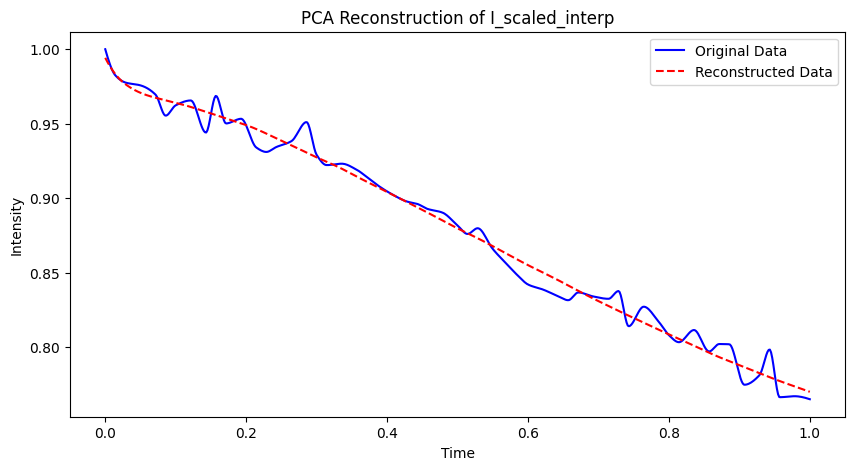

In [72]:
# Transform and inverse transform I_scaled_interp using pca_i_clean
I_scaled_interp_pca = pca_i.transform(I_scaled_interp)
I_scaled_interp_reconstructed = pca_i.inverse_transform(I_scaled_interp_pca)

# Calculate the mean squared error (MSE) between the original and reconstructed data
mse_pca_reconstruction = np.mean((I_scaled_interp - I_scaled_interp_reconstructed) ** 2)
print(f"Mean Squared Error for PCA reconstruction of I_scaled_interp: {mse_pca_reconstruction}")

# Optionally, visualize the original and reconstructed data for a random sample
n = np.random.randint(0, len(I_scaled_interp))  # Randomly select an index for visualization
plt.figure(figsize=(10, 5))
plt.plot(t_uniform, I_scaled_interp[n], label='Original Data', color='blue')
plt.plot(t_uniform, I_scaled_interp_reconstructed[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of I_scaled_interp')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

Experimental RMSE for model_c_clean: 0.37734594201628496
Experimental RMSE for model_h_clean: 0.1889770784500769
Experimental RMSE for model_c_noisy: 0.25993837566967454
Experimental RMSE for model_h_noisy: 0.0971467442109792
Experimental RMSE for model_c_noisy_2: 0.25070196296780056
Experimental RMSE for model_h_noisy_2: 0.08965146252189689
Experimental RMSE for model_c_noisy_3: 0.2533090753681421
Experimental RMSE for model_h_noisy_3: 0.09469487065621948


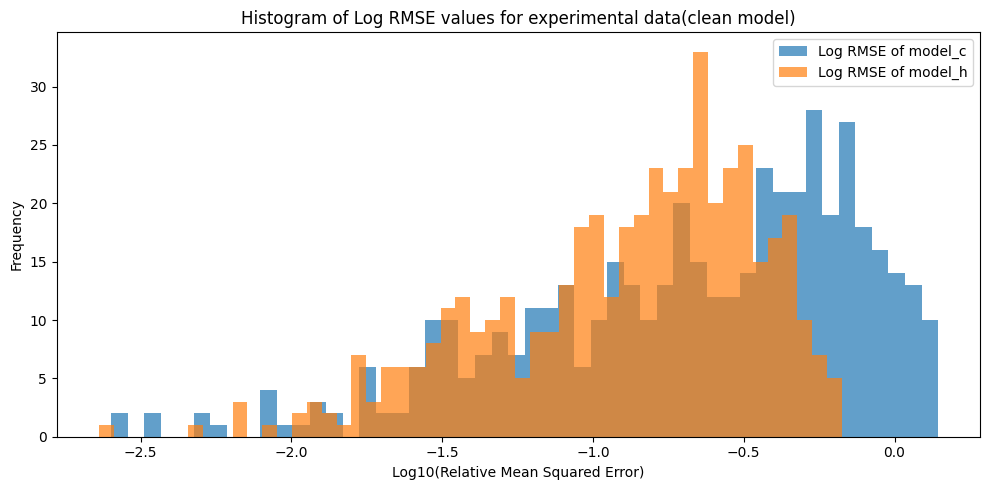

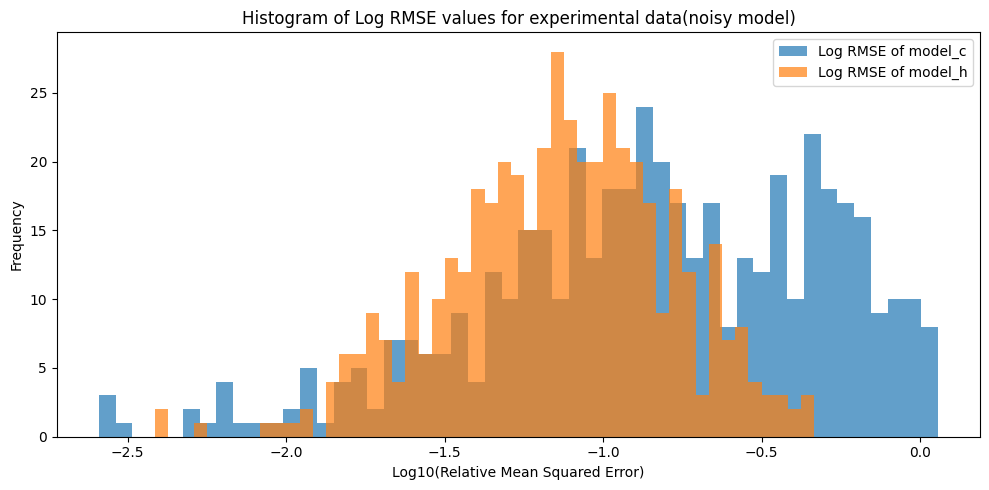

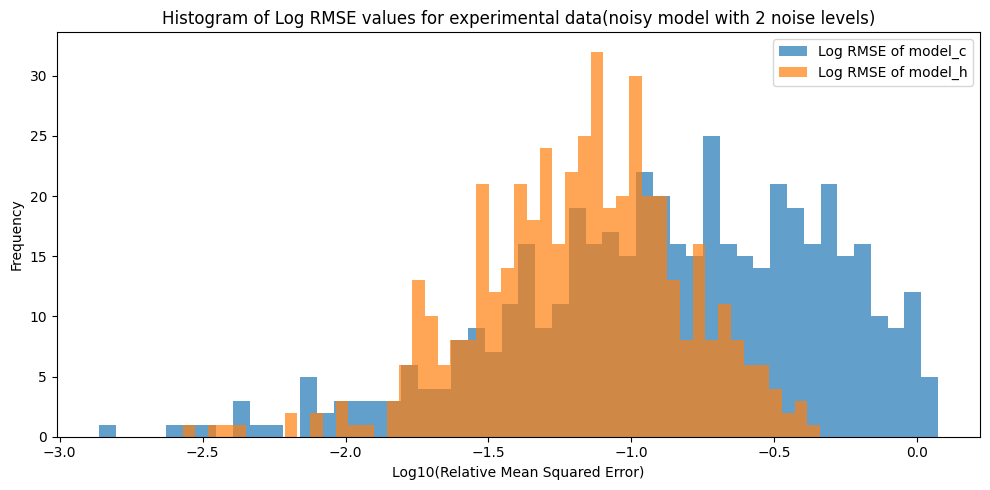

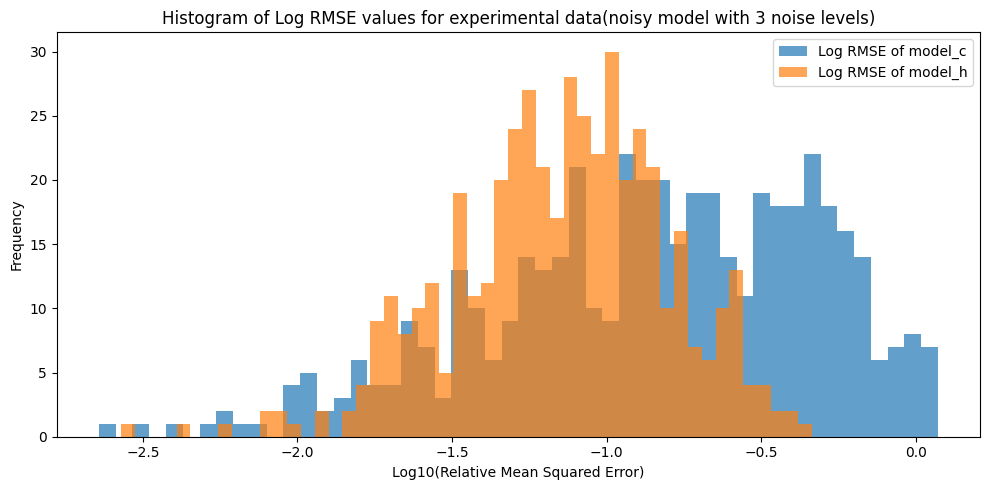

In [87]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

X_test_calculated_pca_clean = pca_i_clean.transform(X_test_expr)
X_test_calculated_pca_noisy = pca_i.transform(X_test_expr)
X_test_calculated_pca_noisy_2 = pca_i_2.transform(X_test_expr)
X_test_calculated_pca_noisy_3 = pca_i_3.transform(X_test_expr)

y_test_c_calculated_pca = pca_c.transform(y_test_c_calculated)
y_test_h_calculated_pca = pca_h.transform(y_test_h_calculated)

# Use trained models to make predictions
predictions_c_calculated_pca_claen = model_c_clean.predict(X_test_calculated_pca_clean)
predictions_h_calculated_pca_clean = model_h_clean.predict(X_test_calculated_pca_clean)

predictions_c_calculated_pca_noisy = model_c_noisy.predict(X_test_calculated_pca_noisy)
predictions_h_calculated_pca_noisy = model_h_noisy.predict(X_test_calculated_pca_noisy)

predictions_c_calculated_pca_noisy_2 = model_c_noisy_2.predict(X_test_calculated_pca_noisy_2)
predictions_h_calculated_pca_noisy_2 = model_h_noisy_2.predict(X_test_calculated_pca_noisy_2)

predictions_c_calculated_pca_noisy_3 = model_c_noisy_3.predict(X_test_calculated_pca_noisy_3)
predictions_h_calculated_pca_noisy_3 = model_h_noisy_3.predict(X_test_calculated_pca_noisy_3)

predictions_c_calculated_clean = pca_c.inverse_transform(predictions_c_calculated_pca_claen)
predictions_h_calculated_clean = pca_h.inverse_transform(predictions_h_calculated_pca_clean)

predictions_c_calculated_noisy = pca_c.inverse_transform(predictions_c_calculated_pca_noisy)
predictions_h_calculated_noisy = pca_h.inverse_transform(predictions_h_calculated_pca_noisy)

predictions_c_calculated_noisy_2 = pca_c_2.inverse_transform(predictions_c_calculated_pca_noisy_2)
predictions_h_calculated_noisy_2 = pca_h_2.inverse_transform(predictions_h_calculated_pca_noisy_2)

predictions_c_calculated_noisy_3 = pca_c_3.inverse_transform(predictions_c_calculated_pca_noisy_3)
predictions_h_calculated_noisy_3 = pca_h_3.inverse_transform(predictions_h_calculated_pca_noisy_3)

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_calculated_clean = np.sqrt(np.mean((predictions_c_calculated_clean - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_clean = np.sqrt(np.mean((predictions_h_calculated_clean - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

rrmse_c_calculated_noisy = np.sqrt(np.mean((predictions_c_calculated_noisy - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_noisy = np.sqrt(np.mean((predictions_h_calculated_noisy - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

rrmse_c_calculated_noisy_2 = np.sqrt(np.mean((predictions_c_calculated_noisy_2 - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_noisy_2 = np.sqrt(np.mean((predictions_h_calculated_noisy_2 - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

rrmse_c_calculated_noisy_3 = np.sqrt(np.mean((predictions_c_calculated_noisy_3 - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_noisy_3 = np.sqrt(np.mean((predictions_h_calculated_noisy_3 - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

print("Experimental RMSE for model_c_clean:", np.mean(rrmse_c_calculated_clean))
print("Experimental RMSE for model_h_clean:", np.mean(rrmse_h_calculated_clean))
print("Experimental RMSE for model_c_noisy:", np.mean(rrmse_c_calculated_noisy))
print("Experimental RMSE for model_h_noisy:", np.mean(rrmse_h_calculated_noisy))
print("Experimental RMSE for model_c_noisy_2:", np.mean(rrmse_c_calculated_noisy_2))
print("Experimental RMSE for model_h_noisy_2:", np.mean(rrmse_h_calculated_noisy_2))
print("Experimental RMSE for model_c_noisy_3:", np.mean(rrmse_c_calculated_noisy_3))
print("Experimental RMSE for model_h_noisy_3:", np.mean(rrmse_h_calculated_noisy_3))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(clean model)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(noisy model)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(noisy model with 2 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy_3), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(noisy model with 3 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()


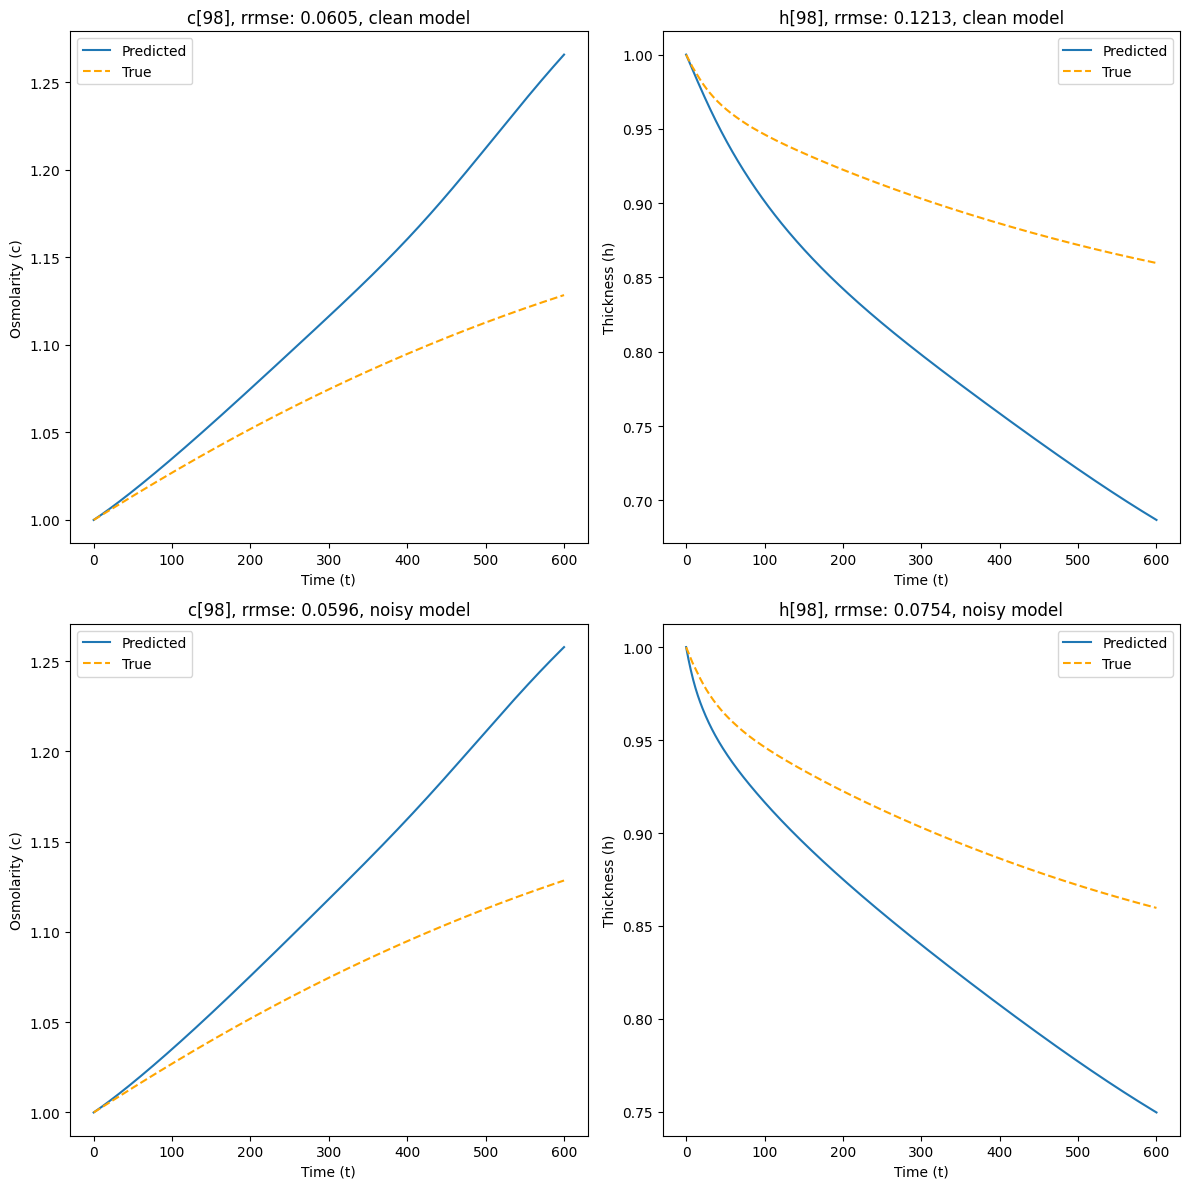

True PCA c: [-6.60424553]
Predicted PCA c (clean): [[-5.0202694  -0.05709995  0.05437863 -0.02932258]]
Predicted PCA c (noisy): [[-5.040182   -0.11028861  0.04214182 -0.02557549]]
True PCA h: [-0.78751606 -0.27338183  0.22492092  0.0185893 ]
Predicted PCA h (clean): [[ 4.2063484   0.38979793 -0.13029331  0.07291135]]
Predicted PCA h (noisy): [[ 5.2212944e+00  2.6332137e-01 -2.0291528e-01  4.9005919e-03]]


In [74]:
n = np.random.choice(len(X_test_calculated_pca_clean))  # Randomly select an index for testing
true_pca_c = y_test_c_calculated_pca[n,:-3]
pred_pca_c_clean = model_c_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = data_h_test_pca[n]
pred_pca_h_clean = model_h_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

In [75]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated_clean = predictions_c_calculated_clean * f_0_experimental[:, np.newaxis]

predictions_f_calculated_noisy = predictions_c_calculated_noisy * f_0_experimental[:, np.newaxis]


In [76]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

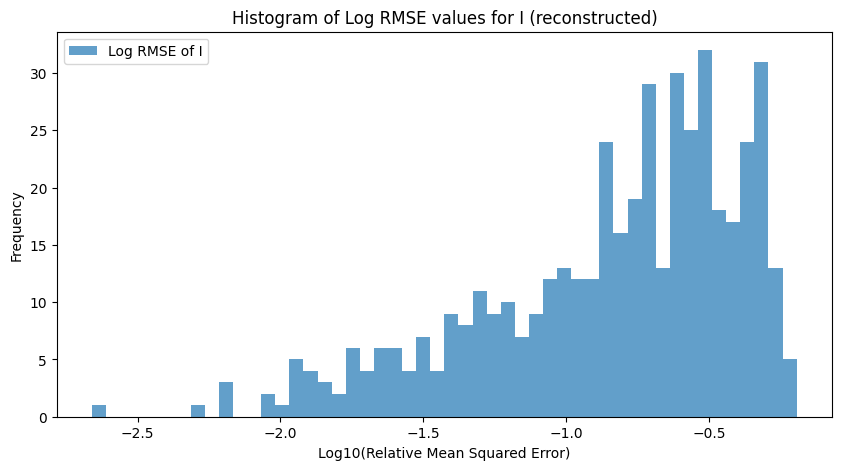

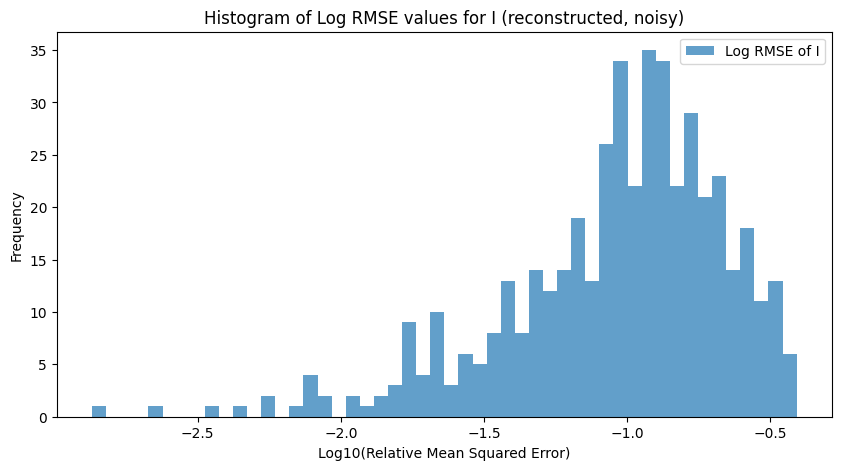

In [77]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred_clean = 1/calculate_I(predictions_h_calculated_clean[:,0].reshape(phi_expanded.shape), predictions_f_calculated_clean[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_clean = calculate_I(predictions_h_calculated_clean, predictions_f_calculated_clean, phi=phi_expanded, I_0=I_0_pred_clean)

I_0_pred_noisy = 1/calculate_I(predictions_h_calculated_noisy[:,0].reshape(phi_expanded.shape), predictions_f_calculated_noisy[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_noisy = calculate_I(predictions_h_calculated_noisy, predictions_f_calculated_noisy, phi=phi_expanded, I_0=I_0_pred_noisy)

# Compute relative MSE for each sample
rel_rmse_I_clean = np.sqrt(np.sum((I_pred_clean - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))
rel_rmse_I_noisy = np.sqrt(np.sum((I_pred_noisy - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))

# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_rmse_I_clean), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_rmse_I_noisy), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed, noisy)')
plt.legend()
plt.show()

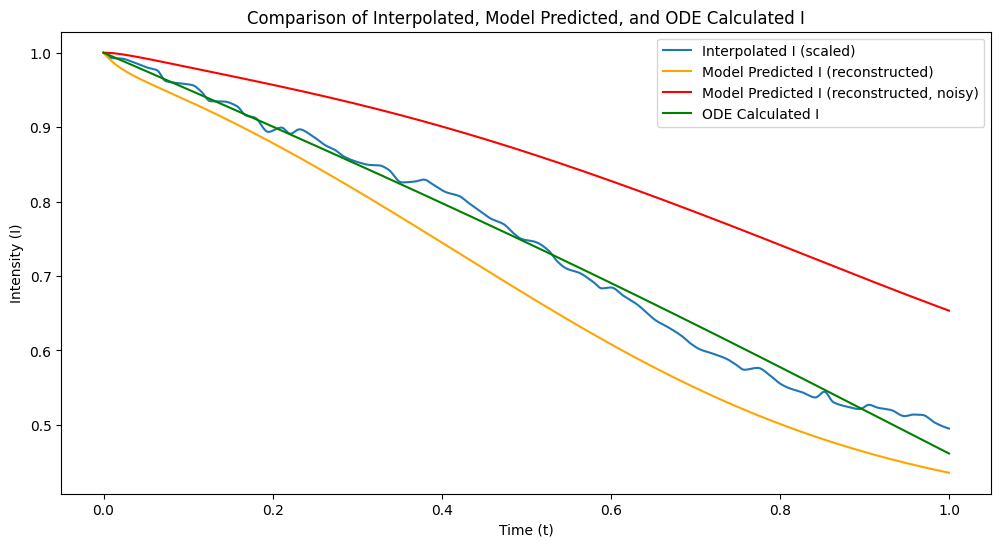

In [78]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

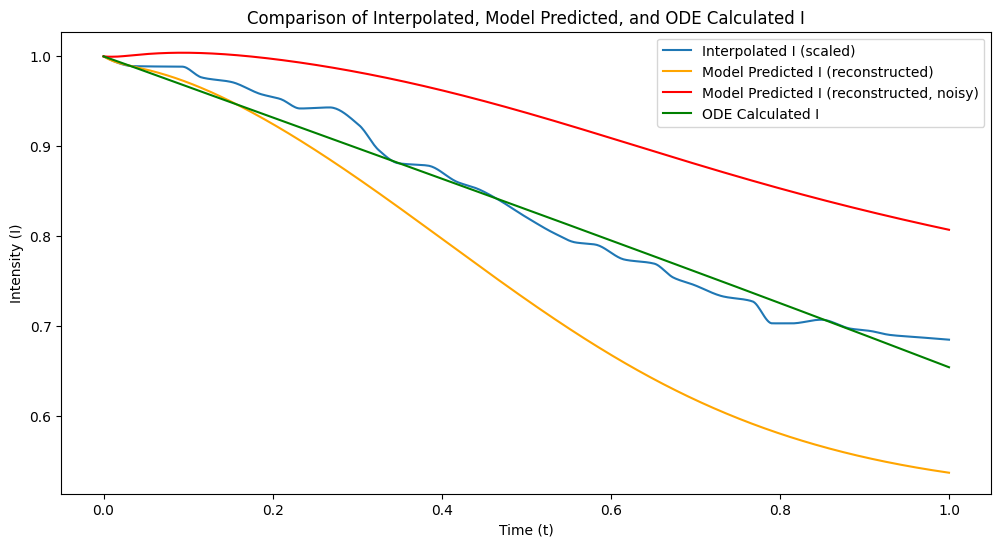

In [79]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [80]:
# import os

# # Path where plots will be stored
# plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/h_plots"
# plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/c_plots"
# plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/f_plots"
# plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/I_plots"
# os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# # Loop through all 467 samples
# for idx in range(467):
#     # Get data for this sample (already loaded in your variables)
#     id = id_array[idx]
#     t = t_scaled_interp[idx]
#     I_exp = I_scaled_interp[idx]
#     h_true = data_h_calculated[idx]
#     c_true = data_c_caluculated[idx]
#     f_true = data_f_calculated[idx]
    
#     I_pred_n = I_pred[idx]
#     h_pred = predictions_h_calculated[idx]
#     c_pred = predictions_c_calculated[idx]
#     f_pred = predictions_f_calculated[idx]
    
#     I_ode = data_I_calculated[idx]
    
#     fig1, ax1 = plt.subplots()
#     ax1.plot(t, I_exp, label='Experimental I (scaled)')
#     ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
#     ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
#     ax1.set_title(f'I for Sample {id}')
#     ax1.set_xlabel('Time Index')
#     ax1.set_ylabel('I')
#     ax1.legend()
#     fig1.tight_layout()
#     fig1.savefig(f"{plot_dir_I}/I_{id}.png")
#     plt.close(fig1)

#     fig2, ax2 = plt.subplots()
#     ax2.plot(t, h_true, label='ODE calculated h')
#     ax2.plot(t, h_pred, label='Model Predicted h')
#     ax2.set_title(f'h for Sample {id}')
#     ax2.set_xlabel('Time Index')
#     ax2.set_ylabel('h')
#     ax2.legend()
#     fig2.tight_layout()
#     fig2.savefig(f"{plot_dir_h}/h_{id}.png")
#     plt.close(fig2)
    
#     fig3, ax3 = plt.subplots()
#     ax3.plot(t, c_true, label='ODE calculated c')
#     ax3.plot(t, c_pred, label='Model Predicted c')
#     ax3.set_title(f'c for Sample {id}')
#     ax3.set_xlabel('Time Index')
#     ax3.set_ylabel('c')
#     ax3.legend()
#     fig3.tight_layout()
#     fig3.savefig(f"{plot_dir_c}/c_{id}.png")
#     plt.close(fig3)
    
#     fig4, ax4 = plt.subplots()
#     ax4.plot(t, f_true, label='ODE calculated f')
#     ax4.plot(t, f_pred, label='Model Predicted f')
#     ax4.set_title(f'f for Sample {id}')
#     ax4.set_xlabel('Time Index')
#     ax4.set_ylabel('f')
#     ax4.legend()
#     fig4.tight_layout()
#     fig4.savefig(f"{plot_dir_f}/f_{id}.png")
#     plt.close(fig4)


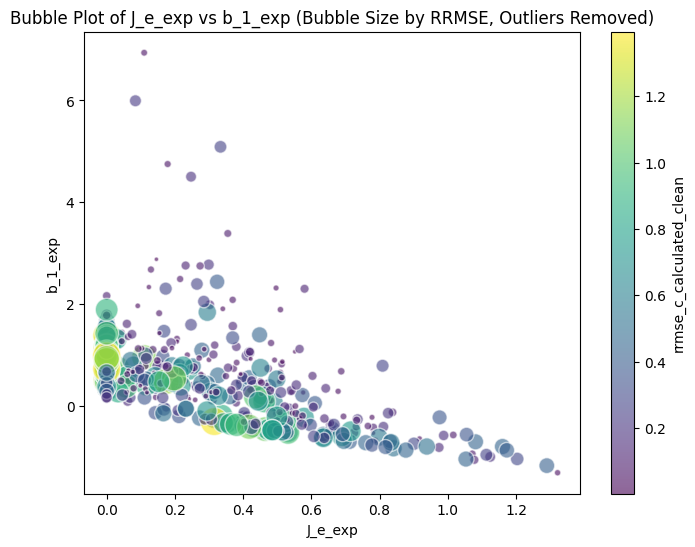

In [81]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated_clean - np.min(rrmse_c_calculated_clean)) / (
    np.max(rrmse_c_calculated_clean) - np.min(rrmse_c_calculated_clean))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated_clean[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


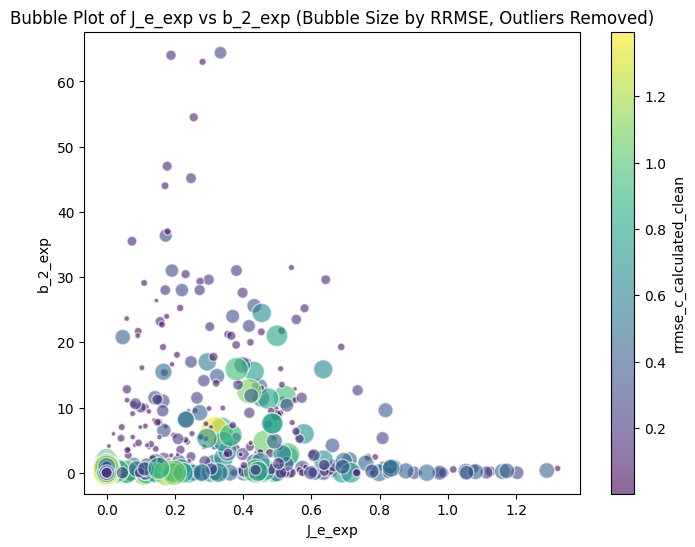

In [82]:
# Remove outliers from b_1_exp
filtered_indices_b2 = b_2_exp < np.max(b_2_exp)

# Apply the same filtering to J_e_exp and other arrays
b_2_exp_filtered = b_2_exp[filtered_indices_b2]
J_e_exp_filtered = J_e_exp[filtered_indices_b2]
sizes_filtered = sizes[filtered_indices_b2]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated_clean[filtered_indices_b2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


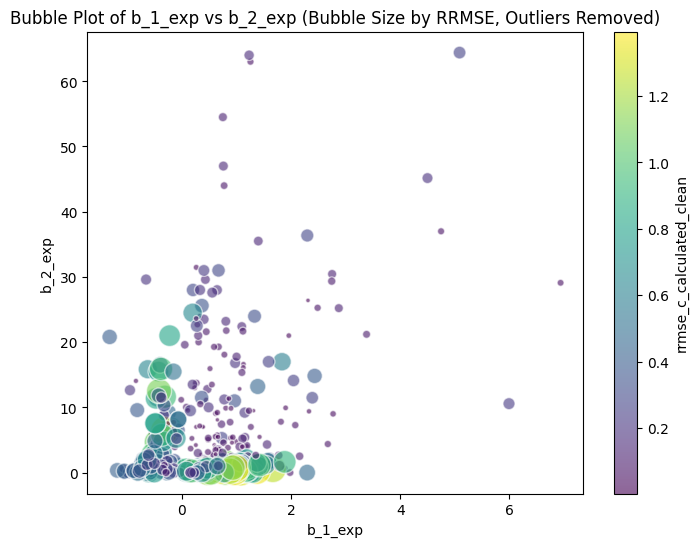

In [83]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()

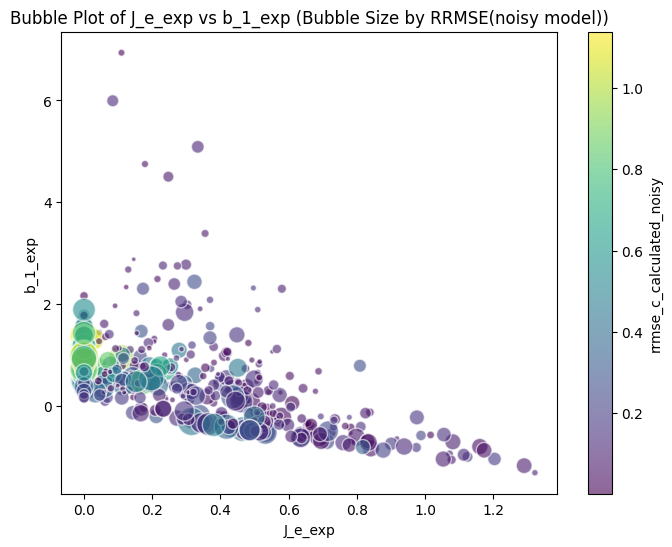

In [84]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated_clean - np.min(rrmse_c_calculated_clean)) / (
    np.max(rrmse_c_calculated_clean) - np.min(rrmse_c_calculated_clean))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_noisy_filtered = rrmse_c_calculated_noisy[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE(noisy model))')
plt.show()


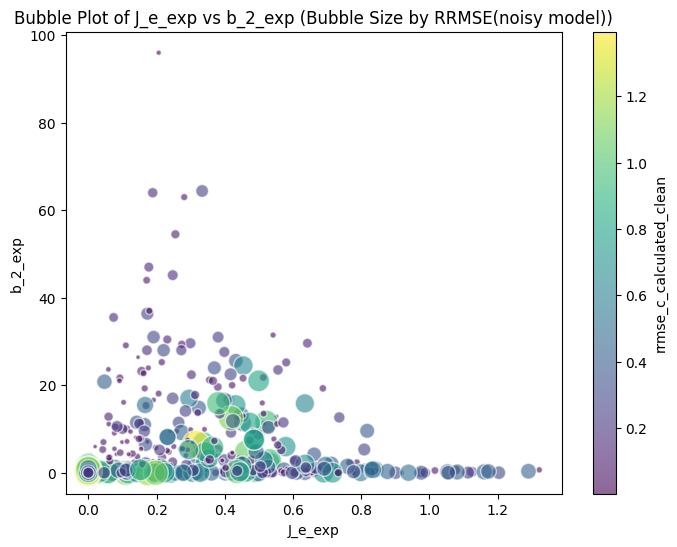

In [85]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp,
    b_2_exp,
    s=sizes,
    c=rrmse_c_calculated_clean,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE(noisy model))')
plt.show()

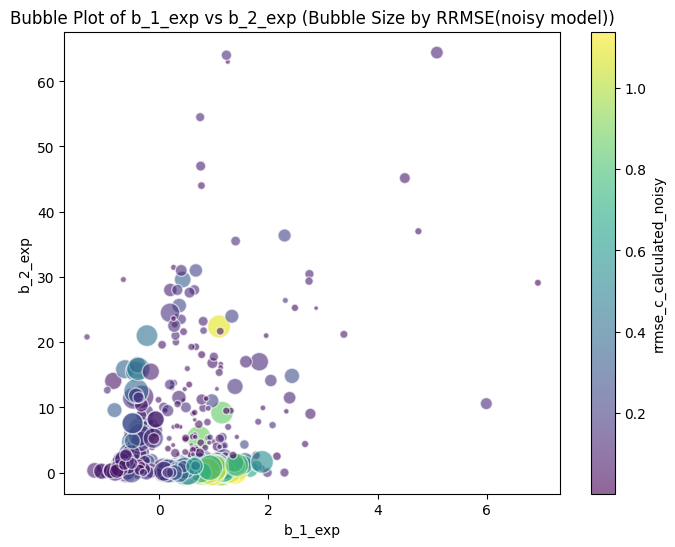

In [86]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE(noisy model))')
plt.show()